# Pattern Recognition - Machine Learning Project1
# Θεοφάνης Μπαρμπαρόσος - 1115202200107

### Dependencies

In [ ]:
%pip install kaggle
# specific versions to avoid collisions
%pip install "numpy<2" "opencv-python==4.9.0.80" "scipy<1.14.0"
%pip install umap-learn
%pip install tabulate

### Randomness & reproducibility

In [69]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

### Fetching data (Kaggle)

Το Dataset που θα χρησιμοποιηθεί είναι το `FaceForensics++ Extracted Dataset (C23)` του χρήστη `Fatima Irshad` και το link για αυτό φαίνεται στο output του επόμενου cell

In [3]:
import kaggle

kaggle.api.authenticate()

# kaggle.api.dataset_download_files('khafie0212/faceforensics-small', unzip=True)
kaggle.api.dataset_download_files('fatimahirshad/faceforensics-extracted-dataset-c23', unzip=True)

### EDA (Exploratory Data Analysis)

In [1]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Number of classes: 6
./FF++C32-Frames/NeuralTextures : 5000 items
./FF++C32-Frames/Original : 5000 items
./FF++C32-Frames/FaceShifter : 5000 items
./FF++C32-Frames/Face2Face : 5000 items
./FF++C32-Frames/FaceSwap : 5000 items
./FF++C32-Frames/Deepfakes : 5000 items
Total number of data: 30000
['NeuralTextures', 'Original', 'FaceShifter', 'Face2Face', 'FaceSwap', 'Deepfakes']
[5000, 5000, 5000, 5000, 5000, 5000]
Total originals: 5000
Total fakes: 25000


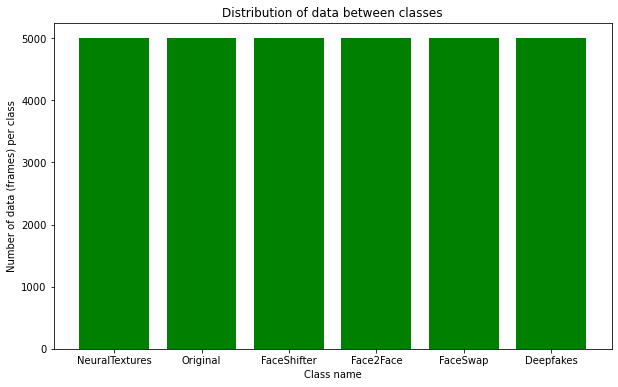

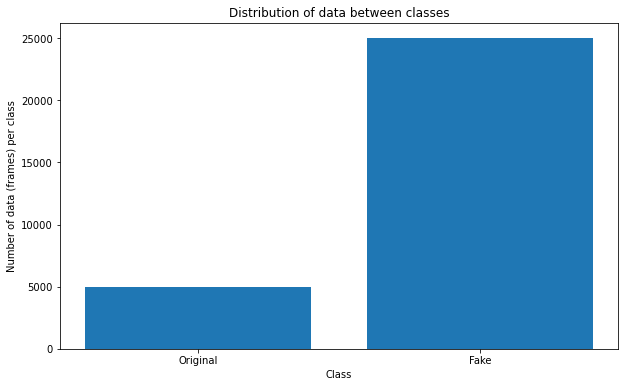

In [ ]:
import os

print(f"Number of classes: {len(os.listdir('FF++C32-Frames'))}")

total_amount = 0
originals = 0
fakes = 0
labels = []
quantities = []
for subdir in os.listdir('FF++C32-Frames'):
    full_subdir = f"./FF++C32-Frames/"+subdir
    print(full_subdir+f" : {len(os.listdir(full_subdir))} items")
    if subdir == "Original":
        originals += len(os.listdir(full_subdir))
    else:
        fakes += len(os.listdir(full_subdir))
    quantities.append(len(os.listdir(full_subdir)))
    labels.append(subdir)
    total_amount += len(os.listdir(full_subdir))

print(f"Total number of data: {total_amount}")

print(labels)
print(quantities)
print(f"Total originals: {originals}")
print(f"Total fakes: {fakes}")

# general plot with  explicit labels
plt.figure(figsize=(10, 6))
plt.bar(labels, quantities, color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of data (frames) per class")
plt.show()

# real/fake distribution plot
plt.figure(figsize=(10, 6))
plt.bar(["Original", "Fake"], [originals, fakes])
plt.title("Distribution of data between classes")
plt.xlabel("Class")
plt.ylabel("Number of data (frames) per class")
plt.show()

### Train-Val-Test Split

Total: 30000 photos
Train set: 21000 photos (70.0%)
Val set: 4500 photos (15.0%)
Test set: 4500 photos (15.0%)


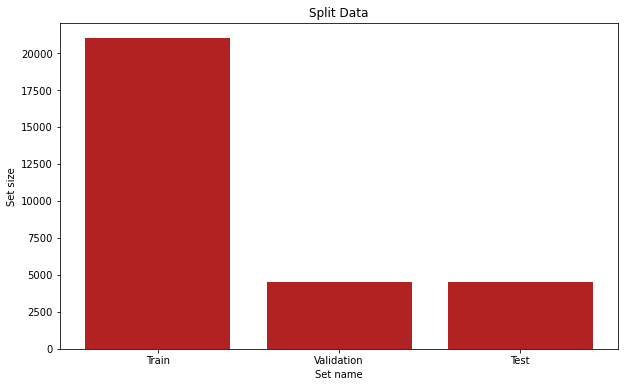

In [3]:
from sklearn.model_selection import train_test_split
import random

base_path = 'FF++C32-Frames'
real_dir = 'Original'
fake_folders = ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']

x = []    # photo paths
y = []    # labels (0=real, 1=fake)

# real
if os.path.exists(os.path.join(base_path, real_dir)):
    for img in os.listdir(os.path.join(base_path, real_dir)):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            x.append(os.path.join(base_path, real_dir, img))
            y.append(0)
else:
    print(f"{os.path.join(base_path, real_dir)}: directory doesn't exist")

# fake
for folder in fake_folders:
    if os.path.exists(os.path.join(base_path, folder)):
        for img in os.listdir(os.path.join(base_path, folder)):
            if img.lower().endswith(('.jpg', 'jpeg', '.png')):
                x.append(os.path.join(base_path, folder, img))
                y.append(1)
    else:
        print(f"{os.path.join(base_path, folder)}: directory doesn't exist")

print(f"Total: {len(x)} photos")



##################################
##                              ##
##         TESTING MODE         ##
##                              ##
##################################
testing = False
if testing:
    print("\n!!!!!!!!!!! TESTING MODE !!!!!!!!!!!\n")
    for i in range(29900):
        index = random.randint(0, len(x)-1)
        del x[index]
        del y[index]
    print(f"Total {len(x)} photos ({len(y)}={len(x)})")



# 1st split (training set)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

# 2nd split (validation and test set)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set: {len(x_train)} photos ({len(x_train)*100/len(x)}%)")
print(f"Val set: {len(x_val)} photos ({len(x_val)*100/len(x)}%)")
print(f"Test set: {len(x_test)} photos ({len(x_test)*100/len(x)}%)")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [len(x_train), len(x_val), len(x_test)], color='firebrick')
plt.title("Split Data")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.show()

### Display class distribution in each set

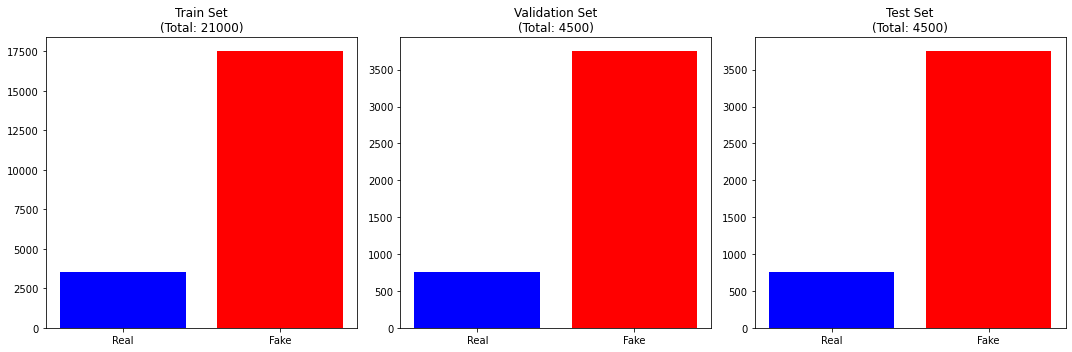

In [4]:
train_counts = [y_train.count(0), y_train.count(1)]
val_counts = [y_val.count(0), y_val.count(1)]
test_counts = [y_test.count(0), y_test.count(1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(["Real", "Fake"], train_counts, color=['blue', 'red'])
axes[0].set_title(f"Train Set\n(Total: {len(y_train)})")

axes[1].bar(["Real", "Fake"], val_counts, color=['blue', 'red'])
axes[1].set_title(f"Validation Set\n(Total: {len(y_val)})")

axes[2].bar(["Real", "Fake"], test_counts, color=['blue', 'red'])
axes[2].set_title(f"Test Set\n(Total: {len(y_test)})")

plt.tight_layout()
plt.show()

## Q0.1 Ανισορροπία Κλάσεων
Όπως φάνηκε από το EDA, το dataset έχει τεράστια ανισορροπία (5.000 Original vs 25.000 Fakes). Σε τέτοιες περιπτώσεις το Accuracy είναι αρκετά παραπλανητικό. Ένα "χαζό" μοντέλο (όπως ο Dummy Classifier) που μαντεύει πάντα την πλειοψηφική κλάση ("Fake"), θα πετύχει περίπου $25000/30000 = 80\%$ accuracy (τελικά πέτυχε $83.33\%$) χωρίς να έχει μάθει απολύτως τίποτα! Γι' αυτό χρησιμοποιούμε το F1-macro score, το οποίο τιμωρεί το μοντέλο αν αγνοήσει τη μειοψηφική κλάση (Real). Για να βοηθήσουμε τους αλγορίθμους στην εκπαίδευση και να μην "πνιγούν" από τα πολλά fakes, χρησιμοποιήσαμε την παράμετρο `class_weight='balanced'` στις μεθόδους (Logistic Regression, SVM, Decision Tree), η οποία δίνει μεγαλύτερη "ποινή" στα σφάλματα της κλάσης Real.

## Q0.2 Ίδια Δεδομένα
Τα ίδια δεδομένα συλλέχθηκαν από δικές μου selfies που τράβηξα τον τελευταίο καιρό αλλά και πιο παλιά. Φρόντισα οι φωτογραφίες που χρησιμοποίησα να μην έχουν τροποποιηθεί καθόλου, ούτε καν διορθώσεις σε φωτεινότητα, αντίθεση, κορεσμό κλπ, ώστε να είναι όσο πιο αυθεντικές γίνεται. Συλλέχθηκαν 20 πραγματικές εικόνες (selfies με διαφορετικό φωτισμό και γωνίες λήψης). Στη συνέχεια, χρησιμοποιήθηκε το εργαλείο εναλλαγής προσώπων [FaceSwapper.ai] για να παραχθούν 20 deepfakes. Τελικά τα artifacts αυτά μοιάζουν αρκετά με τα αποτελέσματα στο dataset του Kaggle.

### Features extraction

In [64]:
def get_feature_names():
    names = []
    channels = ['Red', 'Green', 'Blue'] 
    
    # mean and std per channel
    for c in channels:
        names.append(f"{c}_Mean")
        names.append(f"{c}_Std")
        
    # color histogram (32 bins) and entropy
    for c in channels:
        for b in range(32):
            names.append(f"{c}_HistBin_{b}")
        names.append(f"{c}_Entropy")
        
    # statistics(mean and std) per patch (16 patches x 3 channels x 2 stats)
    for row in range(4):
        for col in range(4):
            for c in channels:
                names.append(f"Patch_[{row},{col}]_{c}_Mean")
                names.append(f"Patch_[{row},{col}]_{c}_Std")
                
    # local deviation of 16 patch means
    for c in channels:
        names.append(f"{c}_Local_Deviation")
        
    # FFT nalysis
    for c in channels:
        names.append(f"{c}_FFT_Mean")
        names.append(f"{c}_FFT_Std")
        names.append(f"{c}_FFT_Max")
        
    return names

# dictionary with feature names for later use
feature_names = get_feature_names()
for i in range(10):
    print(feature_names[i])

Red_Mean
Red_Std
Green_Mean
Green_Std
Blue_Mean
Blue_Std
Red_HistBin_0
Red_HistBin_1
Red_HistBin_2
Red_HistBin_3


In [ ]:
import cv2
import numpy as np
from scipy.stats import entropy

def get_feature_names():
    names = []
    channels = ['Red', 'Green', 'Blue'] 
    
    # mean and std per channel
    for c in channels:
        names.append(f"{c}_Mean")
        names.append(f"{c}_Std")
        
    # color histogram (32 bins) and entropy
    for c in channels:
        for b in range(32):
            names.append(f"{c}_HistBin_{b}")
        names.append(f"{c}_Entropy")
        
    # statistics(mean and std) per patch (16 patches x 3 channels x 2 stats)
    for row in range(4):
        for col in range(4):
            for c in channels:
                names.append(f"Patch_[{row},{col}]_{c}_Mean")
                names.append(f"Patch_[{row},{col}]_{c}_Std")
                
    # local deviation of 16 patch means
    for c in channels:
        names.append(f"{c}_Local_Deviation")
        
    # FFT nalysis
    for c in channels:
        names.append(f"{c}_FFT_Mean")
        names.append(f"{c}_FFT_Std")
        names.append(f"{c}_FFT_Max")
        
    return names

# dictionary with feature names for later use
feature_names = get_feature_names()

def extract_features(img_path):
    # load image
    img = cv2.imread(img_path)
    if img is None:
        return None
        
    # convert to RGB and resize to 256x256
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (256, 256))
    
    features = []
    
    # mean and std per channel
    for i in range(3):
        channel = img_resized[:, :, i]
        features.append(np.mean(channel))
        features.append(np.std(channel))
        
    # color histogram and entropy
    histograms = []
    for i in range(3):
        channel = img_resized[:, :, i]
        hist, _ = np.histogram(channel.flatten(), bins=32, density=True)
        features.extend(hist)
        # entropy
        ent = entropy(hist + 1e-10)
        features.append(ent)

    # statistics(mean and std) per patch (image = 16 patches, patch = 64x64 pixels)
    patch_size = 256 // 4
    patch_means = {0: [], 1: [], 2: []}
    
    for row in range(4):
        for col in range(4):
            # current patch of image
            patch = img_resized[row*patch_size:(row+1)*patch_size, 
                                col*patch_size:(col+1)*patch_size]
            
            for i in range(3):
                channel_patch = patch[:, :, i]
                p_mean = np.mean(channel_patch)
                p_std = np.std(channel_patch)
                
                features.append(p_mean)
                features.append(p_std)
                
                patch_means[i].append(p_mean)
                
    # local deviation of 16 patch means (local inconsistency)
    for i in range(3):
        features.append(np.std(patch_means[i]))
        
    # extra: FFT Analysis
    for i in range(3):
        channel = img_resized[:, :, i]
        magnitude = np.abs(np.fft.fft2(channel))
        features.append(np.mean(magnitude))
        features.append(np.std(magnitude))
        features.append(np.max(magnitude))
        
    return np.array(features)

# feature extraction
def process_dataset(image_paths, labels):
    X_features = []
    y_clean = []

    for path, label in zip(image_paths, labels):
        feat = extract_features(path)
        if feat is not None:
            X_features.append(feat)
            y_clean.append(label)
            
    return np.array(X_features), np.array(y_clean)

print("Extracting features: Train Set...")
X_train_feat, y_train_clean = process_dataset(x_train, y_train)
print(f"Training set shape: {X_train_feat.shape}")


print("\nExtracting features: Validation Set...")
X_val_feat, y_val_clean = process_dataset(x_val, y_val)
print(f"Validation set shape: {X_val_feat.shape}")

print("\nExtracting features: Test Set...")
X_test_feat, y_test_clean = process_dataset(x_test, y_test)
print(f"Test set shape: {X_test_feat.shape}")

Extracting features: Train Set...
Training set shape: (21000, 213)

Extracting features: Validation Set...
Validation set shape: (4500, 213)

Extracting features: Test Set...
Test set shape: (4500, 213)


## Q1.1 Επιπλέον Χαρακτηριστικά

Υλοποίησα επιπλέον τον υπολογισμό της Εντροπίας (Entropy), στατιστικά ανά μικρά patches της εικόνας (local inconsistency), καθώς και ανάλυση στο πεδίο των συχνοτήτων μέσω FFT - Fast Fourier Transform (η επιπλέον επιλογή). Η βασική μας υπόθεση είναι ότι τα deepfakes ενδέχεται να μην αφήνουν εμφανή σημάδια με γυμνό μάτι (στο RGB πεδίο), αλλά δημιουργούν "θόρυβο" ή αφύσικες συχνότητες κατά τη συμπίεση και τη σύνθεση, τα οποία αναδεικνύονται μέσω του FFT και της τοπικής εντροπίας (ανά patch). Εκ πρώτης όψης, τα ιστογράμματα και ο πίνακας συσχέτισης δείχνουν να μην μπορούν τα χαρακτηριστικά να διαφοροποίησουν τις κλάσεις. Στα ιστογράμματα, το ιστόγραμμα fake με το ιστόγραμμα real έχουν πολύ μεγάλο overlap και στον πίνακα, πέρα από την διαγώνιο δεν υπάρχουν άλλα σημεία με σημαντικά πολύ κόκκινο χρώμα, δηλαδή έντονη συσχέτιση, με εξαίρεση πολύ μικρά, μεμονωμένα σημεία.

### Features Preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler


# missing values
missing_train = np.isnan(X_train_feat).sum()
print(f"Missing values in Training set features: {missing_train}")
missing_val = np.isnan(X_val_feat).sum()
print(f"Missing values in Validation set features: {missing_val}")
missing_test = np.isnan(X_test_feat).sum()
print(f"Missing values in Test set features: {missing_test}\n")
# there are no missing values so we don't have to do anything but ifthere were,
# we could replace any NaN value with the mean value of the specific feature

# standardization
scaler = StandardScaler()

# fit AND transform on training data
X_train_scaled = scaler.fit_transform(X_train_feat)

# ONLY transform on val and test sets
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)
print("Regularization complete!\nExample:")
print(f"Mean value of feature 0 in train set is {np.mean(X_train_scaled[:, 0]):.2f}")

Missing values in Training set features: 0
Missing values in Validation set features: 0
Missing values in Test set features: 0

Regularization complete!
Example:
Mean value of feature 0 in train set is 0.00


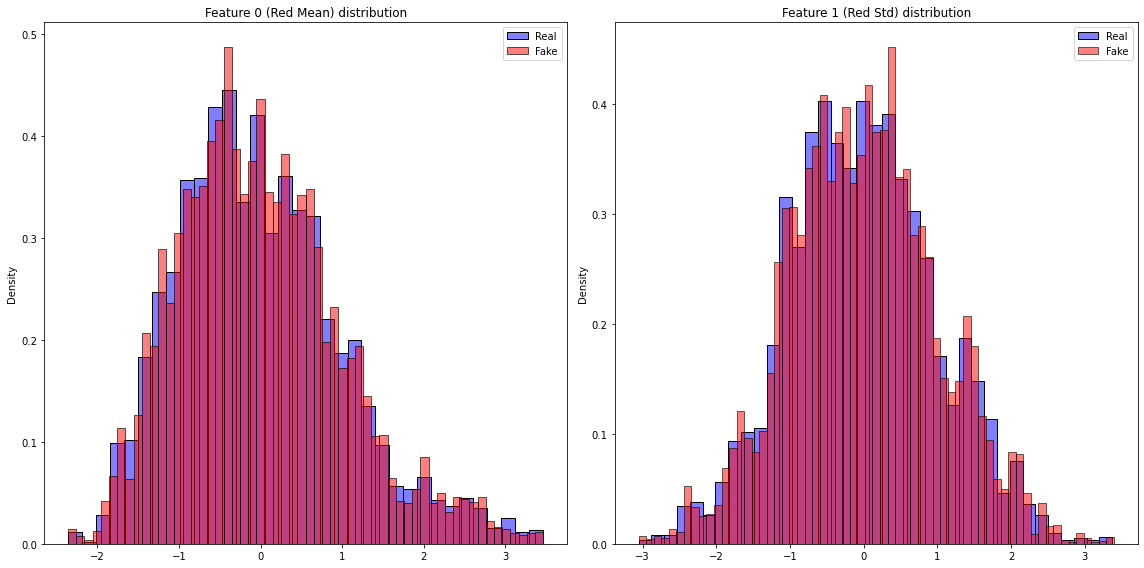


Calculating correlation matrix (213 features x 213 features)...


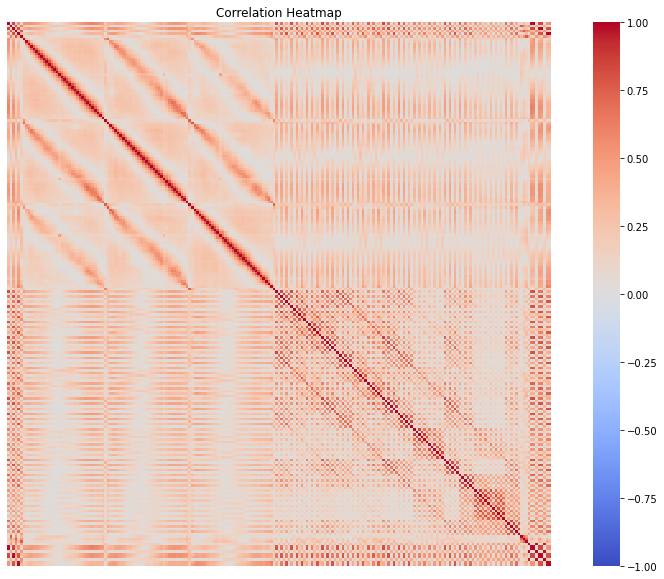


Found 12 pairs of features with correlation > 0.95.
Examples of features that could be deleted due to extreme correlation:
- Feature 0 with feature 205
- Feature 0 with feature 206
- Feature 2 with feature 208
- Feature 2 with feature 209
- Feature 4 with feature 211
- Feature 4 with feature 212
- Feature 204 with feature 207
- Feature 204 with feature 210
- Feature 205 with feature 206
- Feature 207 with feature 210


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

X_real = X_train_scaled[y_train_clean == 0]
X_fake = X_train_scaled[y_train_clean == 1]

feat_1_idx = 0  # feature 0 is the mean value of channel 1(red)
feat_2_idx = 1  # feature 1 is the standard deviation of channel 1(red)

# histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.histplot(X_real[:, feat_1_idx], color='blue', label='Real', ax=axes[0], alpha=0.5, stat="density")
sns.histplot(X_fake[:, feat_1_idx], color='red', label='Fake', ax=axes[0], alpha=0.5, stat="density")
axes[0].set_title("Feature 0 (Red Mean) distribution")
axes[0].legend()

sns.histplot(X_real[:, feat_2_idx], color='blue', label='Real', ax=axes[1], alpha=0.5, stat="density")
sns.histplot(X_fake[:, feat_2_idx], color='red', label='Fake', ax=axes[1], alpha=0.5, stat="density")
axes[1].set_title("Feature 1 (Red Std) distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


# correlation matrix/heatmap
print("\nCalculating correlation matrix (213 features x 213 features)...")
df_train = pd.DataFrame(X_train_scaled)
corr_matrix = df_train.corr().abs()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False, vmin=-1, square=True)
plt.title("Correlation Heatmap")
plt.show()

# finding features with extreme correlation (>0.95)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(column, row) for column in upper_tri.columns for row in upper_tri.index if upper_tri[row][column] > 0.95]

print(f"\nFound {len(high_corr_pairs)} pairs of features with correlation > 0.95.")
print("Examples of features that could be deleted due to extreme correlation:")
for i in range(min(10, len(high_corr_pairs))):
    print(f"- Feature {high_corr_pairs[i][0]} with feature {high_corr_pairs[i][1]}")

## Q1.2 Προεπεξεργασία features

Δεν υπήρχαν missing values καθώς κάθε φωτογραφία στο dataset μπορούσε να χρησιμοποιηθεί κανονικά και να μετατραπεί σε rgb ώστε να εξαχθούν τα χαρακτηριστικά κανονικά. Αν υπήρχαν missing values σε κάποιο χαρακτηριστικό, θα μπορούσε να αντικατασταθεί με τον μέσο όρο αυτού του χαρακτηριστικού από όλες τις εικόνες. Αυτό θα έδινε μία σχετικά αντιπροσωπευτική τιμή στο χαρακτηριστικό της εικόνας χωρίς να επηρεάζει/διαστρεβλώνει την κατανομή του χαρακτηριστικού στο dataset.

Εφαρμόσαμε κανονικοποίηση δεδομένων (Scaling) μέσω του StandardScaler, φέρνοντας όλα τα χαρακτηριστικά σε μέση τιμή 0 και διακύμανση 1. Αυτό είναι απαραίτητο διότι οι αλγόριθμοι που βασίζονται στον υπολογισμό αποστάσεων (όπως ο k-NN και ο SVM) είναι εξαιρετικά ευαίσθητοι στην κλίμακα. Αν το FFT έχει τιμές χιλιάδων και το RGB τιμές 0-255, το μοντέλο θα έδινε τεράστια (και λανθασμένη) σημασία μόνο σε αυτά, αγνοώντας τα υπόλοιπα χαρακτηριστικά, μόνο και μόνο επειδή είναι αρκετά μικρότερα κατ'απόλυτη τιμή. Τέλος, το scaling έγινε με `.fit_transform()` μόνο στο training set για την αποφυγή Data Leakage (=διαρροής πληροφορίας) (αν κάναμε fit_transform και στο val/test set τότε ο εκάστοτε αλγόριθμος θα "μάθει" και το val/test set με αποτέλεσμα να απομνημονεύει το δεύτερο, αντί να γενικεύει σωστά).

## Q1.3 Διαφοροποίηση και Συσχέτιση Χαρακτηριστικών

Διαφοροποίηση: Από τα χαρακτηριστικά που εξάγαγαμε, αναμένουμε ότι οι μέσες τιμές (RGB means) δεν διαφέρουν δραματικά μεταξύ Real και Fake, καθώς τα deepfakes διατηρούν το γενικό χρώμα της εικόνας. Αντίθετα, χαρακτηριστικά όπως το FFT (που καταγράφει τις υψηλές συχνότητες) ή η τοπική διακύμανση/εντροπία στα patches, διαφοροποιούνται περισσότερο. Αυτό συμβαίνει γιατί οι αλγόριθμοι δημιουργίας deepfakes συχνά αφήνουν αδιόρατο "ψηφιακό θόρυβο", θόλωμα ή ασυνέχειες στα όρια (π.χ. γύρω από το πρόσωπο), γεγονός που επηρεάζει τις συχνότητες και την εντροπία της εικόνας.

* Αν πολλά χαρακτηριστικά είναι ισχυρά συσχετισμένα (π.χ. το mean του Red με το mean του Green, ή παραπλήσια bins του ιστογράμματος), ο αλγόριθμος που πλήττεται περισσότερο είναι ο Naive Bayes. Αυτό οφείλεται στο ότι κάνει την αυστηρή μαθηματική υπόθεση της "ανεξαρτησίας των χαρακτηριστικών" (conditional independence). Αν του δώσουμε 5 συσχετισμένα features, θα μετρήσει την ίδια πληροφορία 5 φορές, βγάζοντας υπερβολικά σίγουρες αλλά λανθασμένες πιθανότητες.  
* Η Logistic Regression επηρεάζεται λόγω της πολυσυγγραμμικότητας. Όταν τα χαρακτηριστικά συνδέονται γραμμικά, το μοντέλο αδυνατεί να απομονώσει τη μεμονωμένη επίδραση κάθε χαρακτηριστικού στο αποτέλεσμα. Αυτό καθιστά τα βάρη εξαιρετικά ασταθή, όμως η χρήση Regularization (L1/L2) που της εφαρμόσαμε μετριάζει το πρόβλημα.  
* Ο k-NN είναι πολύ ευαίσθητος, καθώς η συσχέτιση αλλοιώνει τη μέτρηση της απόστασης. Δύο πλήρως συσχετισμένα χαρακτηριστικά ουσιαστικά "διπλασιάζουν" τη βαρύτητα της ίδιας πληροφορίας στον υπολογισμό της απόστασης, παραμορφώνοντας την επιλογή των γειτόνων.  
* Ο SVM είναι συγκριτικά πιο ανθεκτικός, καθώς η βελτιστοποίηση εστιάζει μόνο στα support vectors που ορίζουν το margin. Παρόλα αυτά, τα περιττά χαρακτηριστικά αυξάνουν τις διαστάσεις του προβλήματος χωρίς να προσθέτουν πληροφορία, κάτι που μπορεί να οδηγήσει σε πιο αργή εκπαίδευση ή ελαφρώς χειρότερα υπερεπίπεδα διαχωρισμού.  
* Τέλος, τα Decision Trees μένουν ανεπηρέαστα, καθώς απλώς επιλέγουν ένα από τα συσχετισμένα χαρακτηριστικά για να κάνουν το split και αγνοούν τα υπόλοιπα.

### Dimension reduction and visualizations

/home/fanisbar/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


PCA explained variance ratio: PC1=0.2083, PC2=0.0923
Total information that was preserved after PCA: 30.06%


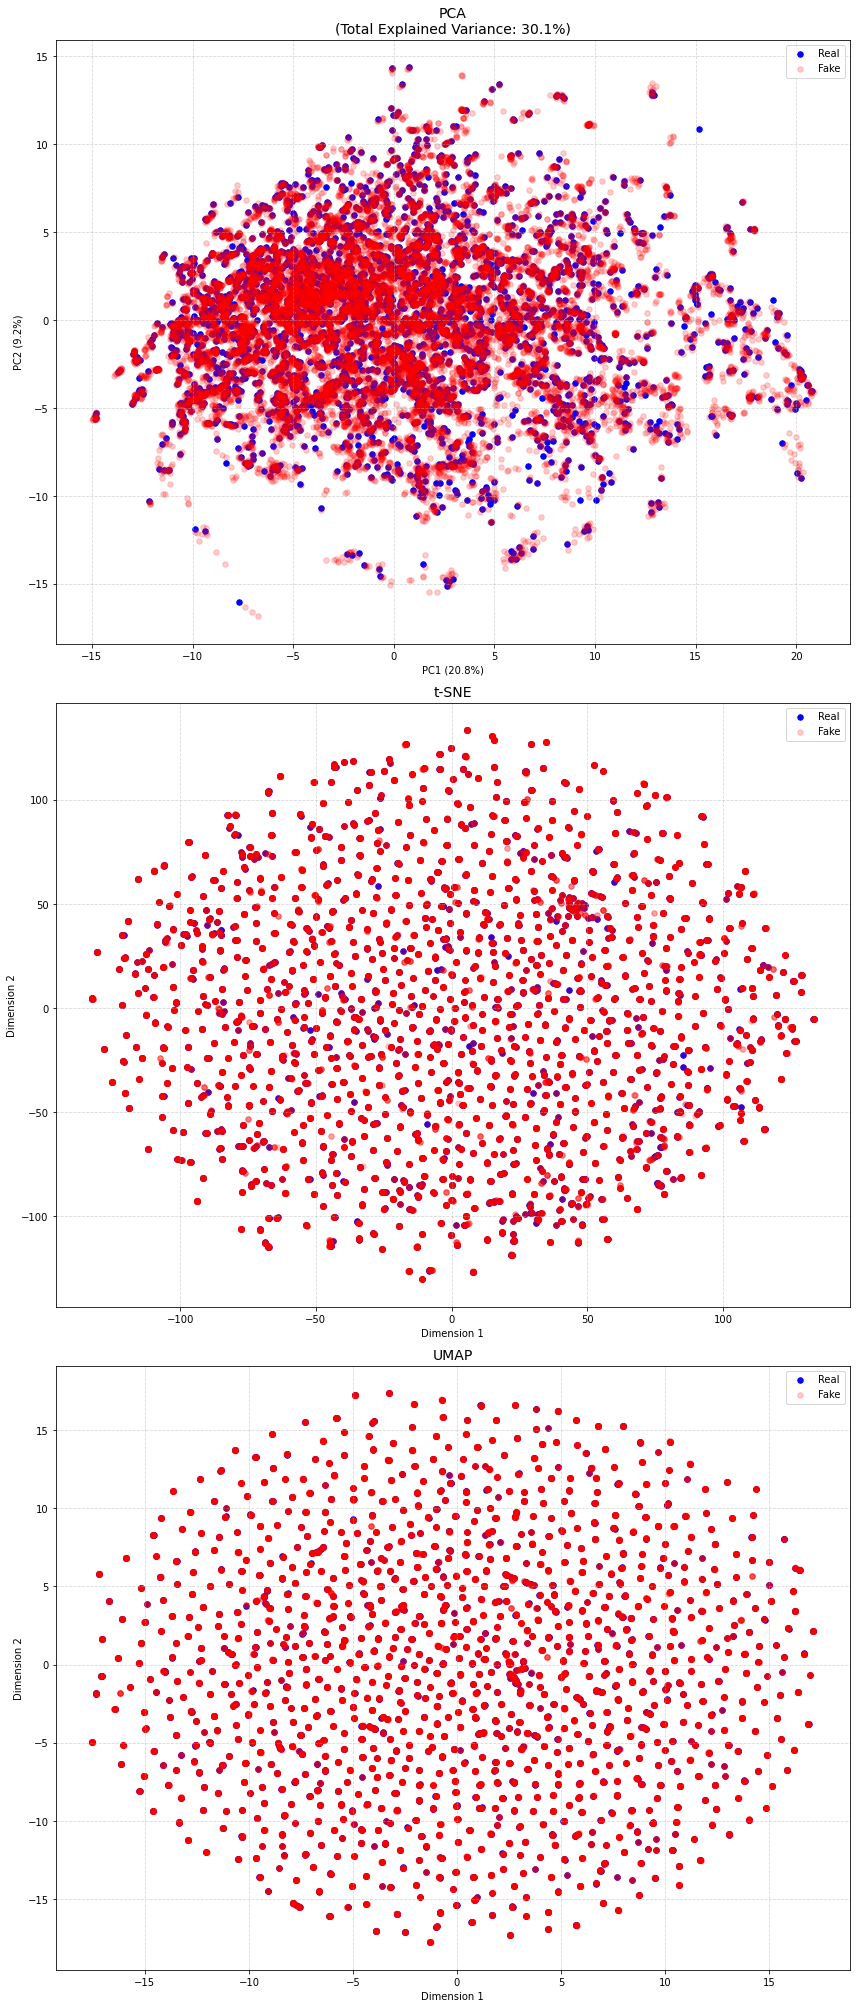

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
total_var = np.sum(pca.explained_variance_ratio_) * 100

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)
# UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_train_scaled)

# visualizations
fig, axes = plt.subplots(3, 1, figsize=(12, 28))

def plot_scatter(ax, X_data, title, xlabel, ylabel):
    # Real (Blue, alpha 1)
    ax.scatter(X_data[y_train_clean == 0, 0], 
               X_data[y_train_clean == 0, 1], 
               color='blue', label='Real', alpha=1.0, s=30)
    # Fake (Red, alpha 0.2)
    ax.scatter(X_data[y_train_clean == 1, 0], 
               X_data[y_train_clean == 1, 1], 
               color='red', label='Fake', alpha=0.2, s=30)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# PCA
plot_scatter(axes[0], X_pca, 
             f"PCA\n(Total Explained Variance: {total_var:.1f}%)", 
             f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", 
             f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
# t-SNE
plot_scatter(axes[1], X_tsne, "t-SNE", "Dimension 1", "Dimension 2")
# UMAP
plot_scatter(axes[2], X_umap, "UMAP", "Dimension 1", "Dimension 2")

print(f"PCA explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}")
print(f"Total information that was preserved after PCA: {total_var:.2f}%")

plt.tight_layout()
plt.show()

## Q1.4 Διαχωρισιμότητα στην Οπτικοποίηση (UMAP/PCA)
Παρατηρώντας την 2D οπτικοποίηση των δεδομένων, είναι εμφανές ότι οι κλάσεις "Real" και "Fake" δεν διαχωρίζονται καθαρά. Η αρχική οπτικοποίηση με PCA φαίνεται χαώδης και δεν δείχνει να μπορούν να διαχωριστούν από ευθεία γραμμή, ενώ οι άλλες δύο(t-SNA και UMAP) οπτικοποιήσεις δημιρουργούν ελάχιστα πιο ξεκάθαρους clusters, οι οποίοι ωστόσο, επίσης δεν είναι γραμμικά διαχωρίσιμοι. Ειδικά στην πρώτη, υπάρχει τεράστια επικάλυψη (overlap) δημιουργώντας ένα ενιαίο, πυκνό "σύννεφο" σημείων, χωρίς ξεκάθαρα όρια.  
Λόγω αυτής της δομής, γραμμικοί αλγόριθμοι (όπως Logistic Regression και ο SVM με Linear kernel) αναμένεται να αποτύχουν παταγωδώς, καθώς είναι αδύνατον να τραβήξουν μια ευθεία γραμμή (hyperplane) που να χωρίζει τα δεδομένα. Αντίθετα, αλγόριθμοι ικανοί να μάθουν μη-γραμμικά, πολύπλοκα όρια απόφασης, όπως ο k-NN, τα Decision Trees και ο SVM με rbf kernel, αναμένεται να αποδώσουν (συγκριτικά) καλύτερα, καταφέρνοντας να απομονώσουν μικρές "γειτονιές" δεδομένων της ίδιας κλάσης μέσα στον θόρυβο.

### Dummy classifier

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Baseline")

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled, y_train_clean)

# prediction on the validation set
y_val_pred_dummy = dummy_clf.predict(X_val_scaled)

# metrics
dummy_acc = accuracy_score(y_val_clean, y_val_pred_dummy)
# F1-macro is used duo to imbalanced data
dummy_f1 = f1_score(y_val_clean, y_val_pred_dummy, average='macro')

print(f"Dummy Classifier - Validation Accuracy: {dummy_acc*100:.2f}%")
print(f"Dummy Classifier - Validation F1-Score (Macro): {dummy_f1:.4f}")
print("\nFrom now on, any algorithm that doesn't beat these baseline results will be discarded!")

Baseline
Dummy Classifier - Validation Accuracy: 83.33%
Dummy Classifier - Validation F1-Score (Macro): 0.4545

From now on, any algorithm that doesn't beat these baseline results will be discarded!


### Training (5-fold Cross Validation)

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import joblib
import warnings

warnings.filterwarnings('ignore')

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_grids = {
    "k-NN": {
        "model": KNeighborsClassifier(),
        "grid": {
            "n_neighbors": [1, 3, 5, 11, 21],
            "metric": ['euclidean', 'cosine']
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "grid": {
            "var_smoothing": [1e-11, 1e-10, 5e-10, 1e-9]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        "grid": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ['saga', 'liblinear'],
            "penalty": ['l1', 'l2']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight='balanced', random_state=42),
        "grid": {
            "max_depth": [3, 5, 10, None],
            "min_samples_leaf": [1, 5, 10]
        }
    },
    "SVM": {
        "model": SVC(class_weight='balanced', random_state=42, cache_size=500),
        "grid": {
            "C": [0.1, 1, 10, 100],
            "kernel": ['linear', 'rbf', 'poly']
        }
    }
}

# models trained with the optimal hyperparameters
best_estimators = {}

print("5-fold cross validation on the sraining set...")
for name, config in models_and_grids.items():
    print(f"\nTraining {name}...")
    if name=="k-NN":
        cores=2
    else:
        cores=-1 # uses all cpu cores
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["grid"],
        cv=cv_strategy,
        scoring='f1_macro', # due to the imbalanced data, we aim to maximize f1-macro, not accuracy
        n_jobs=cores
    )
    
    # .fit splits the training set, train for each split, chooses the best and then trains on THE WHOLE X_train
    grid_search.fit(X_train_scaled, y_train_clean)
    
    # store the best model
    best_estimators[name] = grid_search.best_estimator_
    print(f"The best hyperparameters that were found: {grid_search.best_params_}")
    print(f"Best cross-validation F1-Macro Score: {grid_search.best_score_:.4f}")

print("\n----- Training complete! -----")
joblib.dump(best_estimators, 'my_trained_models.pkl')
print("Trained models successfully stored in 'my_trained_models.pkl'!")

5-fold cross validation on the sraining set...

Training k-NN...
The best hyperparameters that were found: {'metric': 'euclidean', 'n_neighbors': 5}
Best cross-validation F1-Macro Score: 0.4580

Training Naive Bayes...
The best hyperparameters that were found: {'var_smoothing': 1e-11}
Best cross-validation F1-Macro Score: 0.4799

Training Logistic Regression...


/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fanisbar/.local/lib/python3.10/site-packages/sklearn/linear_mode

The best hyperparameters that were found: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation F1-Macro Score: 0.4285

Training Decision Tree...
The best hyperparameters that were found: {'max_depth': None, 'min_samples_leaf': 1}
Best cross-validation F1-Macro Score: 0.4394

Training SVM...
The best hyperparameters that were found: {'C': 100, 'kernel': 'linear'}
Best cross-validation F1-Macro Score: 0.4102

----- Training complete! -----
Trained models successfully stored in 'my_trained_models.pkl'!


Loading trained models...
Evaluation on the validation set


,Model,Best Params,Validation Accuracy,Validation F1-Macro
1,Naive Bayes,var_smoothing=1e-11,0.788444,0.464500
0,k-NN,"n_neighbors=5, metric=euclidean",0.824667,0.458154
3,Decision Tree,"max_depth=None, min_samples_leaf=1",0.679333,0.440241
2,Logistic Regression,"C=0.01, penalty=l1, solver=saga",0.449333,0.408821
4,SVM,"C=100, kernel=linear",0.470222,0.402600


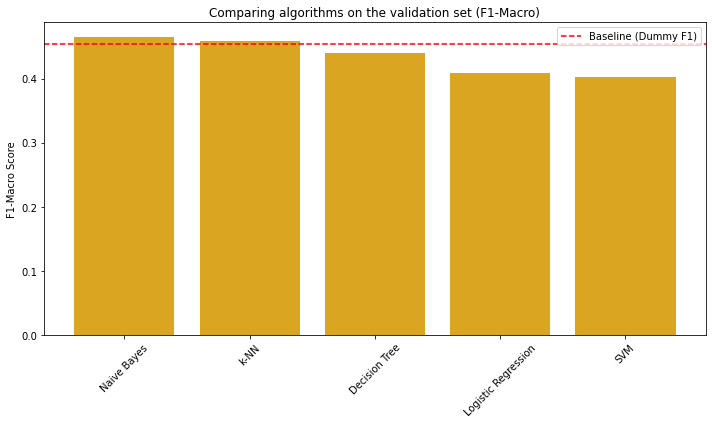

Found 213 samples that were misclassified by all algorithms.
indices: 15, 27, 45
file names: FF++C32-Frames/Original/259_f0.jpg, FF++C32-Frames/Original/615_f4.jpg, FF++C32-Frames/Original/379_f0.jpg
classified as: Fake, Fake, Fake (by all 5 models)
true classes: Real, Real, Real



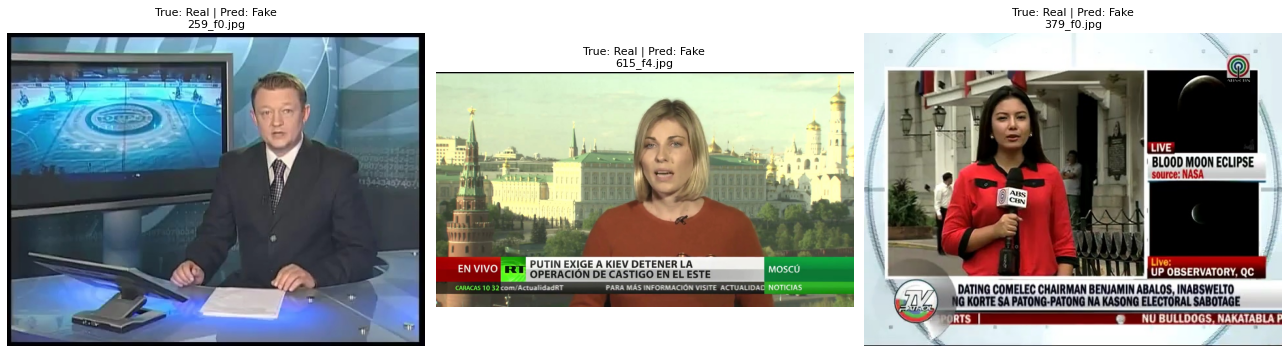


Final evaluation of the best model on the test set
The best model was: Naive Bayes

Test Accuracy: 79.18%
Test F1-Macro: 0.4650

Detailed report (Classification Report):
              precision    recall  f1-score   support

    Real (0)       0.10      0.03      0.05       750
    Fake (1)       0.83      0.94      0.88      3750

    accuracy                           0.79      4500
   macro avg       0.46      0.49      0.46      4500
weighted avg       0.71      0.79      0.74      4500



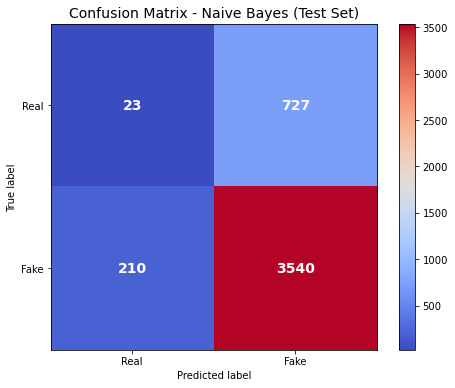

In [49]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
import matplotlib.image as mpimg

print("Loading trained models...")
# loading the models from the previous cell, trained with the optimal hyperparameters
best_estimators = joblib.load('my_trained_models.pkl')

# baseline Dummy
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled, y_train_clean)

# Dummy validation
y_val_pred_dummy = dummy_clf.predict(X_val_scaled)
dummy_val_acc = accuracy_score(y_val_clean, y_val_pred_dummy)
dummy_val_f1 = f1_score(y_val_clean, y_val_pred_dummy, average='macro')

# Dummy test
y_test_pred_dummy = dummy_clf.predict(X_test_scaled)
dummy_test_acc = accuracy_score(y_test_clean, y_test_pred_dummy)
dummy_test_f1 = f1_score(y_test_clean, y_test_pred_dummy, average='macro')

print("Evaluation on the validation set")
val_results = []
markdown_table_rows = [] # only for the markdown table of Q2.1

markdown_table_rows.append(f"| Dummy (Baseline) | - | {dummy_val_acc*100:.2f}% | {dummy_val_f1*100:.2f}% | {dummy_test_acc*100:.2f}% | {dummy_test_f1*100:.2f}% |")

grid_keys = {
    "k-NN": ["n_neighbors", "metric"],
    "Naive Bayes": ["var_smoothing"],
    "Logistic Regression": ["C", "penalty", "solver"],
    "Decision Tree": ["max_depth", "min_samples_leaf"],
    "SVM": ["C", "kernel"]
}

# model misclassifications
all_errors = []

# our 5 models
for name, model in best_estimators.items():
    # val predictions
    y_val_pred = model.predict(X_val_scaled)
    # store the mistakes
    errors = (y_val_pred != y_val_clean)
    all_errors.append(errors)
    val_acc = accuracy_score(y_val_clean, y_val_pred)
    val_f1 = f1_score(y_val_clean, y_val_pred, average='macro')

    # test predictions
    y_test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test_clean, y_test_pred)
    test_f1 = f1_score(y_test_clean, y_test_pred, average='macro')

    params = model.get_params()
    best_params_str = ", ".join([f"{k}={params[k]}" for k in grid_keys.get(name, [])])
    val_results.append({"Model": name, "Best Params": best_params_str, "Validation Accuracy": val_acc, "Validation F1-Macro": val_f1})
    markdown_table_rows.append(f"| {name} | {best_params_str} | {val_acc*100:.2f}% | {val_f1*100:.2f}% | {test_acc*100:.2f}% | {test_f1*100:.2f}% |")

results_df = pd.DataFrame(val_results).sort_values(by="Validation F1-Macro", ascending=False)
display(results_df)
# only for the markdown table later
##############  IGNORE  ##############
# print("| Αλγόριθμος | Βέλτιστες Υπερπαράμετροι | Validation Acc(%) | Validation F1(%) | Test Acc(%) | Test F1(%) |")
# print("| :--- | :--- | :--- | :--- | :--- | :--- |")
# for row in markdown_table_rows:
#     print(row)
##############  IGNORE  ##############

# visualization
plt.figure(figsize=(10, 6))
colors = ['gray' if model == "Dummy (Baseline)" else 'goldenrod' for model in results_df["Model"]]
bars = plt.bar(results_df["Model"], results_df["Validation F1-Macro"], color=colors)
plt.axhline(y=dummy_f1, color='red', linestyle='--', label='Baseline (Dummy F1)')
plt.title("Comparing algorithms on the validation set (F1-Macro)")
plt.ylabel("F1-Macro Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# finding comon misclassifications
# logical "and" produces true, only if all values are true (all 5 models misclassified the given sample)
common_errors_mask = np.logical_and.reduce(all_errors)
common_error_indices = np.where(common_errors_mask)[0]

print(f"Found {len(common_error_indices)} samples that were misclassified by all algorithms.")
if len(common_error_indices) >= 3:
    indices_to_show = common_error_indices[:3]
    true_classes = y_val_clean.iloc[indices_to_show].values if hasattr(y_val_clean, 'iloc') else y_val_clean[indices_to_show]
    pred_classes = 1 - true_classes
    label_map = {0: "Real", 1: "Fake"}
    true_labels = [label_map[tc] for tc in true_classes]
    pred_labels = [label_map[pc] for pc in pred_classes]
    try:
        wrong_filenames = x_val.iloc[indices_to_show].values if hasattr(x_val, 'iloc') else [x_val[i] for i in indices_to_show]
        print(f"indices: {', '.join(map(str, indices_to_show))}")
        print(f"file names: {', '.join(map(str, wrong_filenames))}")
        print(f"classified as: {', '.join(pred_labels)} (by all 5 models)")
        print(f"true classes: {', '.join(true_labels)}\n")

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        for i, ax in enumerate(axes):
            filename = wrong_filenames[i]

            if isinstance(filename, str) and os.path.exists(filename):
                try:
                    img = mpimg.imread(filename)
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, 'Couldn\'t open image', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, f"File not found: {filename}\n", ha='center', va='center', fontsize=8)
            ax.set_title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}\n{filename.split('/')[-1]}", fontsize=11)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    except NameError:
        print("Something went wrong with  x_val!")
else:
    print("Didn't find 3 samples, misclassified by all 5 models/algorithms.")

print("\nFinal evaluation of the best model on the test set")
best_model_name = results_df[results_df["Model"] != "Dummy (Baseline)"].iloc[0]["Model"]
final_best_model = best_estimators[best_model_name]

print(f"The best model was: {best_model_name}\n")

# prediction on the !unknown! test set
y_test_pred = final_best_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test_clean, y_test_pred)
test_f1 = f1_score(y_test_clean, y_test_pred, average='macro')

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test F1-Macro: {test_f1:.4f}\n")
print("Detailed report (Classification Report):")
print(classification_report(y_test_clean, y_test_pred, target_names=["Real (0)", "Fake (1)"]))

# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_clean, 
    y_test_pred, 
    display_labels=["Real", "Fake"], 
    cmap='coolwarm',
    text_kw={'color': 'white', 'fontsize': 14, 'weight': 'bold'},
    ax=ax
)
plt.title(f"Confusion Matrix - {best_model_name} (Test Set)", fontsize=14)
plt.show()

## Q2.1
| Αλγόριθμος | Βέλτιστες Υπερπαράμετροι | Validation Acc(%) | Validation F1(%) | Test Acc(%) | Test F1(%) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Dummy (Baseline) | - | 83.33% | 45.45% | 83.33% | 45.45% |
| k-NN | n_neighbors=5, metric=euclidean | 82.47% | 45.82% | 82.78% | 45.42% |
| Naive Bayes | var_smoothing=1e-11 | 78.84% | 46.45% | 79.18% | 46.50% |
| Logistic Regression | C=0.01, penalty=l1, solver=saga | 44.93% | 40.88% | 43.76% | 39.91% |
| Decision Tree | max_depth=None, min_samples_leaf=1 | 67.93% | 44.02% | 67.40% | 43.49% |
| SVM | C=100, kernel=linear | 47.02% | 40.26% | 48.18% | 41.56% |

## Q2.2 Confusion Matrix
Στο Confusion Matrix του καλύτερου αλγορίθμου, παρατηρούμε μεγάλο αριθμό λαθών και στις δύο κατευθύνσεις, με χαρακτηριστική έφεση στα False Positives (ταξινομεί πολλές αληθινές εικόνες ως Fake).  
Αυτό συμβαίνει διότι τα χαρακτηριστικά που χρησιμοποιήθηκαν (χρωματικά ιστογράμματα, στατιστικά FFT, εντροπία) καταγράφουν την "υφή" και τον θόρυβο σε επίπεδο pixels, αλλά στερούνται "σημασιολογικής" κατανόησης (π.χ. δεν ξέρουν τι είναι το "μάτι" ή το "στόμα"). Έτσι, αν μια πραγματική φωτογραφία έχει τραβηχτεί με κακό φωτισμό, φθηνή κάμερα (άρα έχει θόρυβο αισθητήρα) ή έχει υποστεί βαρύ compression (π.χ. JPEG), αυξάνεται η εντροπία της και αποκτά FFT συχνότητες που μοιάζουν πάρα πολύ με τα ψηφιακά "σημάδια" μιας deepfake εικόνας.

## Q2.3 Κοινά Λάθη Αλγορίθμων
Εντοπίσαμε 213 δείγματα που ταξινομήθηκαν λάθος από όλους τους αλγορίθμους. Οπτικοποιώντας τα πρώτα 3, μία υπόθεση είναι ότι ευθύνονται τα χαρακτηριστικά που εξάγαμε, αλλά και στα ίδια τα δεδομένα. Σε προηγμένα deepfakes, η αντικατάσταση του προσώπου γίνεται τόσο ομαλά που η περιοχή γύρω από το πρόσωποχρωματίζεται σχεδόν τέλεια (color blending), οπότε οι απλές μαθηματικές μετρικές διακύμανσης και μέσης τιμής αδυνατούν να βρουν ανωμαλίες. Χρειαζόμαστε χαρακτηριστικά πιο εξελιγμένων μοντέλων που να εστιάζουν σε ασυμφωνίες στον φωτισμό 3D επιφανειών ή τις αντανακλάσεις στα μάτια.

## Q2.4 Επιλογή Αλγορίθμου vs Accuracy (Η απάντηση στον Υπεύθυνο)
Η απάντησή στον υπεύθυνο θα ήταν η εξής: "Το accuracy από μόνο του είναι παραπλανητικό, ειδικά σε μη-ισορροπημένα δεδομένα όπως τα δικά μας. Όμως, πέρα από τις μετρικές, η επιλογή του αλγορίθμου εξαρτάται από τον στόχο της εφαρμογής, λαμβάνοντας υπόψη τρεις πυλώνες:"  
* **Ερμηνευσιμότητα (Interpretability):** Σε κρίσιμους τομείς (π.χ. δημοσιογραφία, νομικές υποθέσεις), το να πούμε απλά "το μοντέλο είπε ότι είναι deepfake" δεν αρκεί. Πρέπει να εξηγήσουμε το γιατί. Ένα απλό Decision Tree μας επιτρέπει να δούμε ακριβώς ποιο χαρακτηριστικό (π.χ. "το FFT > 0.8") οδήγησε στην απόφαση, ενώ ο SVM με RBF kernel (που έχει υψηλότερο F1) δεν είναι παρά ένα "μαύρο κουτί".
* **Υπολογιστικό Κόστος (Inference Time / Memory):** Αν η εταιρεία θέλει να ελέγχει χιλιάδες εικόνες το δευτερόλεπτο, ο k-NN είναι απαγορευτικός γιατί υπολογίζει αποστάσεις με όλα τα δεδομένα του training set (είναι αργός και θέλει τεράστια μνήμη RAM). Η Logistic Regression, παρότι ίσως έχει ελαφρώς χειρότερο F1, εκτελεί τον έλεγχο ταχύτατα (ένας απλός πολλαπλασιασμός πινάκων).
* Στη βιομηχανία προτιμούμε συχνά το πιο απλό μοντέλο **(Occam's Razor)** που καλύπτει τις προδιαγραφές μας, καθώς είναι φθηνότερο να εκπαιδευτεί, να αναβαθμιστεί και να ενσωματωθεί σε συστήματα παραγωγής.

Total samples: 40
Real: 20, Fake: 20

Extracting features from the new dataset...

Evaluation on custom dataset:
F1-Macro: 0.4203
Accuracy: 52.50%



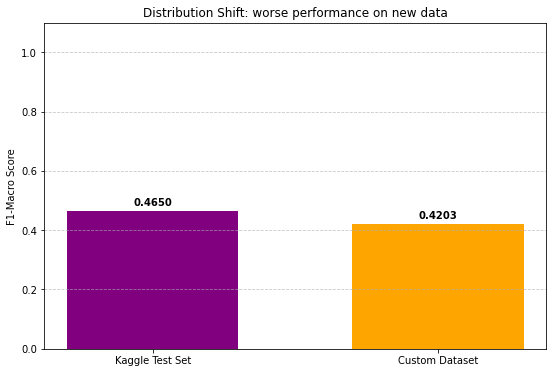

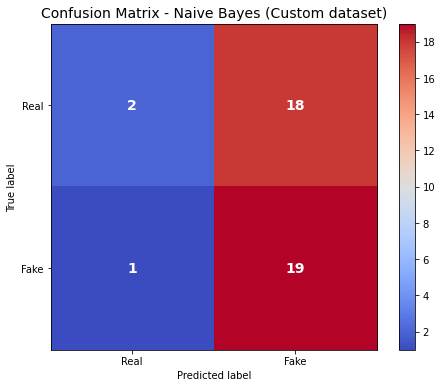

In [40]:
import glob

custom_real_dir = 'my_dataset/original'
custom_fake_dir = 'my_dataset/deepfakes'

custom_files = []
custom_labels = []

# original (label 0)
for f in glob.glob(os.path.join(custom_real_dir, '*')):
    custom_files.append(f)
    custom_labels.append(0)

# deepfakes (label 1)
for f in glob.glob(os.path.join(custom_fake_dir, '*')):
    custom_files.append(f)
    custom_labels.append(1)

print(f"Total samples: {len(custom_files)}")
print(f"Real: {custom_labels.count(0)}, Fake: {custom_labels.count(1)}")

# feature extraction
print("\nExtracting features from the new dataset...")
X_custom_raw, custom_labels_clean = process_dataset(custom_files, custom_labels) 

# scaling (transform only)
X_custom_scaled = scaler.transform(X_custom_raw)

# prediction using the best model
y_custom_pred = final_best_model.predict(X_custom_scaled)

# evaluation
custom_f1 = f1_score(custom_labels_clean, y_custom_pred, average='macro')
custom_acc = accuracy_score(custom_labels_clean, y_custom_pred)

print(f"\nEvaluation on custom dataset:")
print(f"F1-Macro: {custom_f1:.4f}")
print(f"Accuracy: {custom_acc*100:.2f}%\n")

# visual comparison
comparison_df = pd.DataFrame({
    'Dataset': ['Kaggle Test Set', 'Custom Dataset'],
    'F1-Macro Score': [test_f1, custom_f1]
})

plt.figure(figsize=(9, 6))
colors = ['purple', 'orange']
bars = plt.bar(comparison_df['Dataset'], comparison_df['F1-Macro Score'], color=colors, width=0.6)

plt.ylabel('F1-Macro Score')
plt.title('Distribution Shift: worse performance on new data')
plt.ylim(0, 1.1)

# exact values over each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    custom_labels_clean, 
    y_custom_pred, 
    display_labels=["Real", "Fake"], 
    cmap='coolwarm',
    text_kw={'color': 'white', 'fontsize': 14, 'weight': 'bold'},
    ax=ax
)
plt.title(f"Confusion Matrix - {best_model_name} (Custom dataset)", fontsize=14)
plt.show()

## Q3.0 Εξαγωγή χαρακτηριστικών από ίδια δεδομένα

Δεν υπήρξε κάποιο πρόβλημα κατά την εξαγωγή χαρακτηριστικών. Κάποιες εικόνες ήταν σε μορφή .jpg ενώ άλλες ήταν σε .png ωστόσο τα ίδια χαρακτηριστικά παρήχθησαν κανονικά για όλες τις εικόνες του dataset. Αν υπήρχαν missing values, όπως και με το Kaggle dataset θα μπορούσαν να αντικατασταθούν με τον μέσο όρο.

## Q3.1 Aπόδοση συγκριτκά με το Kaggle dataset

Αξιολογώντας το καλύτερο μοντέλο (Naive Bayes) στο Custom Dataset, παρατηρούμε δραματική πτώση: Το F1-Macro έπεσε στο 0.42 (από 0.45) και το Accuracy στο 52.5%(83.33%). Το μοντέλο κυριολεκτικά "μαντεύει". Η πτώση αυτή αποδεικνύει την ύπαρξη του Distribution Shift. Το μοντέλο δεν έμαθε τον γενικό κανόνα "τι είναι deepfake", αλλά έμαθε τα συγκεκριμένα, τεχνικά "ψεγάδια" (compression artifacts) των αλγορίθμων που χρησιμοποιήθηκαν στο FaceForensics++. Τα ίδια(custom) δεδομένα παρήχθησαν από αντίστοιχα εργαλεία, αφήνοντας όμως ίχνη, τα οποία το μοντέλο δεν μπορεί να διακρίνει.

## Q3.2 Σενάριο: Σύστημα Συναλλαγών
Οι αιτίες της πτώσης μπορεί να είναι:
* Data: Διαφορετικές καταναλωτικές συνήθειες (π.χ. διαφορετικές ώρες αιχμής, μεγέθη ποσών ή χρήση μετρητών vs καρτών στη νέα αγορά).
* Concept: Διαφορετικές μέθοδοι απάτης που χρησιμοποιούνται τοπικά.
Πριν την εγκατάσταση θα έπρεπε να πραγματοποιηθεί στατιστικός έλεγχος για να δούμε αν οι κατανομές των χαρακτηριστικών στη νέα αγορά διαφέρουν από την αρχική, και να κάνουμε επαρκές testing πριν εγκαταστήσουμε αλλαγές (ίσως 1-2 εβδομάδες).

In [68]:
# mean value of each feature for both datasets
kaggle_means = np.mean(X_test_scaled, axis=0)
custom_means = np.mean(X_custom_scaled, axis=0)

deviations = np.abs(kaggle_means - custom_means)

df_dev = pd.DataFrame({
    'Feature name': feature_names,
    'Mean (Kaggle)': kaggle_means,
    'Mean (Ίδια)': custom_means,
    'Deviation': deviations
})

# choose the 5 features with the largest deviation
top_5_dev = df_dev.sort_values(by='Deviation', ascending=False).head(5)

# only for the markdown table below
print(top_5_dev.to_markdown(index=False))

| Feature name         |   Mean (Kaggle) |   Mean (Ίδια) |   Deviation |
|:---------------------|----------------:|--------------:|------------:|
| Patch_[0,2]_Red_Std  |      0.0047179  |     -0.877705 |    0.882423 |
| Patch_[0,1]_Red_Std  |      0.0264497  |     -0.835455 |    0.861905 |
| Patch_[3,1]_Blue_Std |     -0.00563663 |     -0.808333 |    0.802696 |
| Patch_[3,1]_Red_Std  |     -0.013409   |     -0.810127 |    0.796718 |
| Patch_[0,3]_Blue_Std |      0.00101657 |     -0.775694 |    0.77671  |


## Q3.3 Απόκλιση χαρακτηριστικών και εξωτερικοί παράγοντες
Όπως προκύπτει από τον πίνακα, τα 5 χαρακτηριστικά που αποκλίνουν περισσότερο είναι οι τυπικές αποκλίσεις (std) συγκεκριμένων τοπικών τμημάτων (patches), και ειδικότερα αυτών που βρίσκονται στα άκρα της εικόνας (γραμμή 0 - πάνω άκρη, και γραμμή 3 - κάτω άκρη) στα κανάλια Red και Blue.

Εξωτερικοί παράγοντες που εξηγούν την απόκλιση: > Τα patches αυτά αντιστοιχούν στο φόντο (background) των εικόνων και αρκετές φορές σε "banners" ειδήσεων/τίτλων. Στο Kaggle dataset, τα βίντεο συχνά αφορούν παρουσιαστές ειδήσεων ή άτομα σε ελεγχόμενο περιβάλλον, με σταθερό καδράρισμα και παρόμοια φόντα. Αντίθετα, οι εικόνες του δικού μου Custom Dataset (π.χ. selfies) έχουν τραβηχτεί εξωτερικά ή σε μη ελεγχόμενα περιβάλλοντα, με διαφορετικό φωτισμό και γωνίες λήψης. Έτσι, η διακύμανση των pixels στο φόντο άλλαξε δραματικά, οδηγώντας στις τεράστιες αυτές αποκλίσεις.

| Feature name         |   Mean (Kaggle) |   Mean (Ίδια) |   Παρατηρήσεις |
|:---------------------|----------------:|--------------:|------------:|
| Patch_[0,2]_Red_Std  |      0.0047179  |     -0.877705 |     |
| Patch_[0,1]_Red_Std  |      0.0264497  |     -0.835455 |     |
| Patch_[3,1]_Blue_Std |     -0.00563663 |     -0.808333 |     |
| Patch_[3,1]_Red_Std  |     -0.013409   |     -0.810127 |     |
| Patch_[0,3]_Blue_Std |      0.00101657 |     -0.775694 |     |

## Q3.4 Ευθύνη Λαθών και Αντικατάσταση

Ναι, τα χαρακτηριστικά αυτά ευθύνονται άμεσα για τα περισσότερα λάθη. Το γεγονός ότι απέκλιναν τόσο πολύ αποδεικνύει ότι τα μοντέλα μας υπερπροσαρμόστικαν στα δεδομένα του FaceForensics++ αντί να μάθουν να αναγνωρίζουν τα χαρακτηριστικά ενός πλαστού προσώπου. Όταν το μοντέλο είδε τα νέα, άγνωστα φόντα των δικών μας εικόνων, τα χαρακτηριστικά πήραν ακραίες αρνητικές τιμές μετά το scaling (κοντά στο -0.8) και οδήγησαν τον ταξινομητή σε τελείως λανθασμένες προβλέψεις.

Θα καταργούσα εντελώς τη λογική του στατικού χωρισμού της εικόνας σε 16 grid patches (Patch_Mean/Std). Αντ' αυτού, το πρώτο βήμα προεπεξεργασίας που θα πρόσθετα θα ήταν ένας αλγόριθμος αναγνώρισης προσώπου. Έτσι, θα μπορούσα να κάνω crop μόνο στο πρόσωπο, αφαιρώντας τελείως το φόντο. Από στο "καθαρό" πρόσωπο θα εξήγαγα χαρακτηριστικά που αφορούν την υφή, τα οποία θα εστίαζαν μόνο στα τεχνητά artifacts του deepfake (π.χ. θόλωμα γύρω από το στόμα ή τα μάτια).

## Q3.5/Q3.6

## Q3.7 Επανασχεδιασμός Συλλογής Δεδομένων

Λαμβάνοντας υπόψη ότι τα χαρακτηριστικά με τη μεγαλύτερη απόκλιση ήταν τα ακριανά patches της εικόνας (φόντο), αν επανασχεδίαζα τη συλλογή των δικών μου δεδομένων θα στόχευα σε ένα dataset που εξαλείφει τις ψευδείς συσχετίσεις και αξιολογεί τον πραγματικό στόχο:

* **Εστίαση αποκλειστικά στο Πρόσωπο:**: Το πιο κρίσιμο λάθος ήταν η χρήση ολόκληρης της εικόνας. Προτού καν δημιουργήσω το custom dataset, θα χρησιμοποιούσα έναν αλγόριθμο εντοπισμού προσώπου για να "κόψω" και να αποθηκεύσω αυστηρά και μόνο τα πρόσωπα. Έτσι, το φόντο (όπου παρατηρήθηκε η τεράστια απόκλιση στα ακριανά patches) αφαιρείται εντελώς, και το distribution shift περιορίζεται αμιγώς στα χαρακτηριστικά του προσώπου.

* **Στοχευμένη Ποικιλομορφία:** Αντί να προσπαθήσω να μιμηθώ τα "αποστειρωμένα" βίντεο του Kaggle, θα φρόντιζα το δικό μου dataset να περιέχει σκόπιμα μεγάλη ποικιλία από γωνίες λήψης, εκφράσεις και φωτισμούς. Σκοπός είναι το dataset μου να αντιπροσωπεύει raw, τυχαία δεδομένα του πραγματικού κόσμου, ώστε να αποτελεί ένα αυστηρό και ρεαλιστικό benchmark αξιολόγησης.